<a href="https://colab.research.google.com/github/CliffAD/LAB-Projects/blob/main/Fashion_Classifier_ILP_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Clifford Anthony Dsouza")
print("Intermediate level project - Fashion_Classifier")
print("Prof Dr Durga Sharma")

Clifford Anthony Dsouza
Intermediate level project - Fashion_Classifier
Prof Dr Durga Sharma


In [ ]:
pip install tensorflow numpy matplotlib scikit-learn

Loading Fashion MNIST dataset...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,858 (620.54 KB)

 Trainable params: 158,858 (620.54 KB)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 71s 92ms/step - accuracy: 0.6467 - loss: 0.9616 - val_accuracy: 0.7575 - val_loss: 0.6515
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 90ms/step - accuracy: 0.7565 - loss: 0.6669 - val_accuracy: 0.7993 - val_loss: 0.5323
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 89ms/step - accuracy: 0.7859 - loss: 0.5886 - val_accuracy: 0.8179 - val_loss: 0.5004
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 67s 89ms/step - accuracy: 0.8041 - loss: 0.5459 - val_accuracy: 0.8403 - val_loss: 0.4284
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 66s 89ms/step - accuracy: 0.8169 - loss: 0.5109 - val_accuracy: 0.8512 - val_loss: 0.3978
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 88ms/step - accuracy: 0.8274 - loss: 0.4829 - val_accuracy: 0.8533 - val_loss: 0.3971
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 66s 89ms/step - accuracy: 0.8360 - loss: 0.4597 - val_accuracy: 0.8587 - val_loss: 0.3802
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 89ms/step - accuracy: 0.

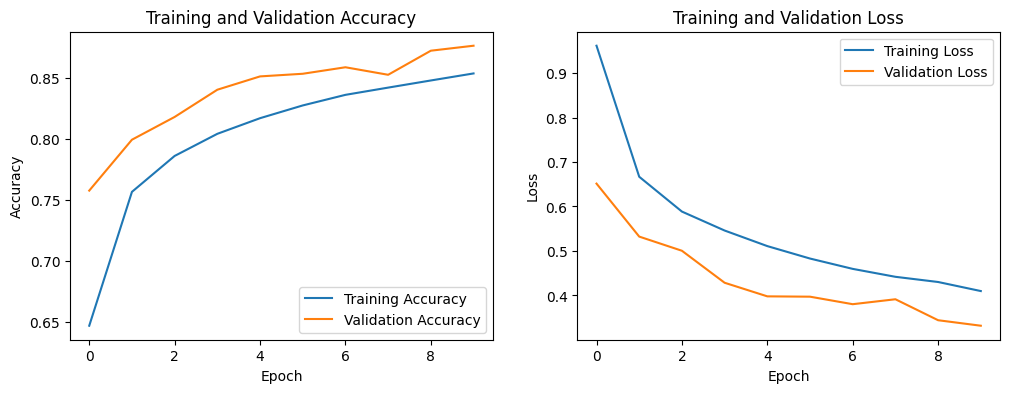

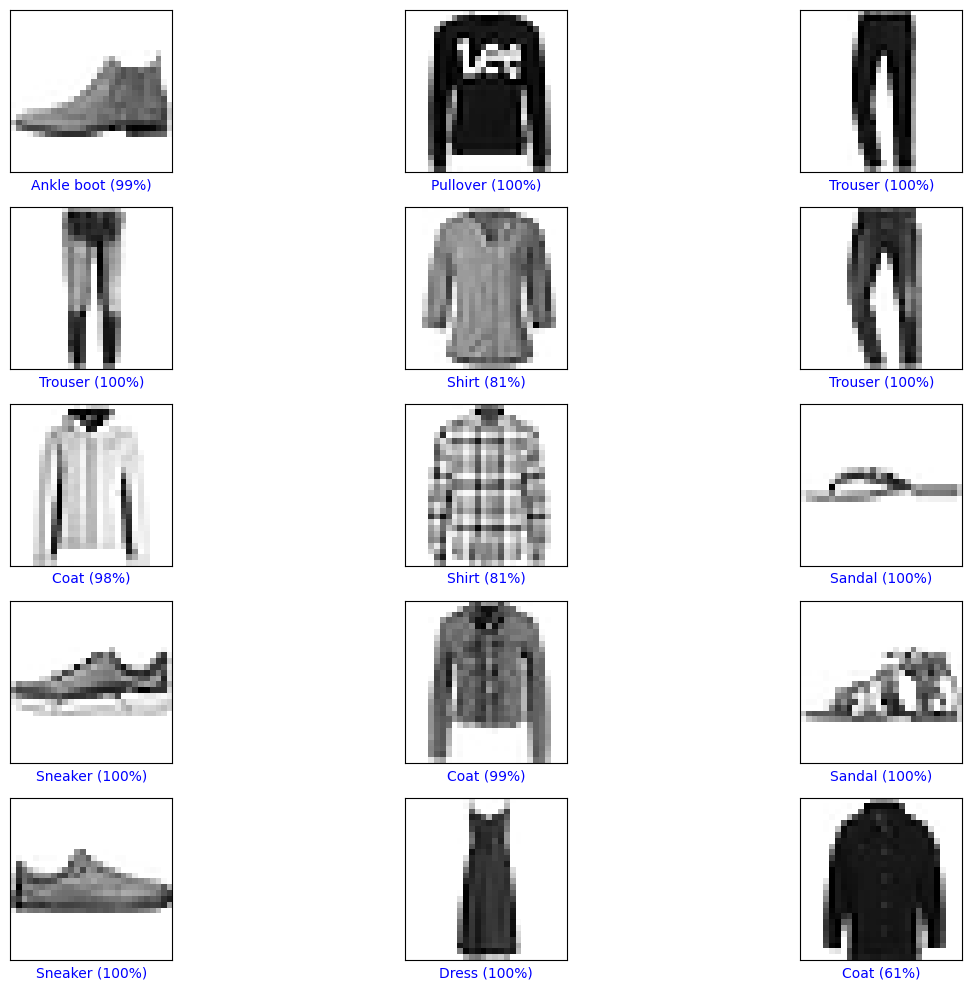

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Data: Load the Fashion MNIST dataset
# This dataset contains 70,000 grayscale images of 10 fashion categories.
print("Loading Fashion MNIST dataset...")
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Define class names for readable output
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 2. Image Preprocessing
# Normalize pixel values to be between 0 and 1
train_images = train_images / 255.0
test_images = test_images / 255.0

# Reshape data to include channel dimension (28, 28, 1) for the CNN
train_images = train_images.reshape((-1, 28, 28, 1))
test_images = test_images.reshape((-1, 28, 28, 1))

print(f"Training data shape: {train_images.shape}")
print(f"Test data shape: {test_images.shape}")

# 3. Data Augmentation
# Create a data augmentation layer to improve model generalization
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal", input_shape=(28, 28, 1)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# 4. Model: Convolutional Neural Network (CNN)
model = models.Sequential([
    # Apply augmentation
    data_augmentation,

    # CNN Layer 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # CNN Layer 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # CNN Layer 3
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Flatten 3D outputs to 1D for Dense layers
    layers.Flatten(),

    # Dense Layers
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Dropout to prevent overfitting
    layers.Dense(10, activation='softmax') # Output layer (10 classes)
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', # Cross-entropy loss
              metrics=['accuracy'])

model.summary()

# 5. Train the Model
print("\nStarting training...")
history = model.fit(train_images, train_labels,
                    epochs=10,
                    batch_size=64,
                    validation_split=0.2,
                    verbose=1)

# 6. Evaluation: Accuracy, Precision, Recall, F1 Score
print("\nEvaluating model on test data...")
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

# Generate predictions
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

# Detailed Classification Report (Precision, Recall, F1-score)
print("\nClassification Report:")
print(classification_report(test_labels, predicted_labels, target_names=class_names))

# 7. Visualization: Plot Training Accuracy vs Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

# Optional: Visualize a few predictions
def plot_image(i, predictions_array, true_label, img):
    predictions_array, true_label, img = predictions_array, true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img.reshape(28, 28), cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel(f"{class_names[predicted_label]} ({100*np.max(predictions_array):2.0f}%)", color=color)

# Plot the first 15 test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions[i], test_labels, test_images)
plt.tight_layout()
plt.show()

In [ ]:
Project Title: Fashion Classifier (CNN) using Fashion MNIST

Description:
The objective of this project is to build and train a Convolutional Neural Network (CNN) model that can classify clothing images from the Fashion MNIST dataset into 10 categories (e.g., T-shirt/top, Trouser, Sneaker, etc.). The project also evaluates the model using accuracy and a detailed classification report.

Dataset:
Source: Included dataset from TensorFlow tf.keras.datasets.fashion_mnist

Description:
Contains 70,000 grayscale images
28 × 28 pixels per image
10 fashion categories
Split into training and test sets
Steps Performed
Data Cleaning / Preparation

Loaded dataset using fashion_mnist.load_data()
Normalized pixel values by dividing by 255.0 (scales values to 0–1)
Exploratory Data Analysis (EDA)

The notebook focuses mainly on model training and visualization of results (accuracy/loss and example predictions).
No detailed tabular EDA is shown in the provided code.
Visualization

Plotted:
Training vs Validation Accuracy
Training vs Validation Loss
Displayed 15 sample test predictions, coloring outputs:
Blue = correct prediction
Red = incorrect prediction
Model Building

Implemented a CNN using TensorFlow Keras Sequential
Added data augmentation:
RandomFlip(horizontal)
RandomRotation(0.1)
RandomZoom(0.1)
CNN architecture includes:
Conv2D + MaxPooling blocks
Flatten
Dense layer with Dropout(0.5)
Final Dense(10, activation='softmax') for 10 classes

Results
Key findings:
The model is evaluated on the test dataset
It generates predictions and produces a detailed precision, recall, F1-score report for each class
Metrics (if applicable):
Test Accuracy (model.evaluate)
Classification report (Precision, Recall, F1-score) using sklearn.metrics.classification_report

Tools Used
Python
TensorFlow / Keras
NumPy
Matplotlib
scikit-learn (classification report)
(Also imports seaborn though it isn’t clearly used in the shown section)

Conclusion
This project successfully demonstrates an end-to-end pipeline for image classification using CNN + data augmentation on the Fashion MNIST dataset. It preprocesses and normalizes image data, trains a CNN model for 10 epochs, evaluates performance on the test set, and visualizes both training progress (accuracy/loss curves) and prediction outcomes (correct vs incorrect samples).

Author: Clifford Anthony DSouza